In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

def gbdt_estimator_past(data, N_remove, N_estimate, link, normalize_data=True, epochs=50, save_figures=False, save_path=None, show_figs=False):
    print(f'Estimating for link {link}')

    # Extract the error values and new features
    dates = data['Date']
    # Feature engineering: Extract day of the week and month from the 'Date' column
    data['DayOfWeek'] = data['Date'].dt.dayofweek  # Monday=0, Sunday=6
    data['Month'] = data['Date'].dt.month  # Extracting month
    
    # Prepare the data for model input (including new features)
    feature_columns = ['Error', 'DayOfWeek', 'Month']
    data_features = data[feature_columns]

    # Normalize data if requested
    if normalize_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_values = scaler.fit_transform(data_features)
    else:
        data_values = data_features.values

    # Number of samples
    N = len(data_values)
    
    # Split the data
    if N_remove == 0:
        past_data_values = data_values
        past_dates = dates
        last_date = past_dates.iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else: 
        past_data_values = data_values[:-N_remove] # All the error values except for the last N_remove days
        future_data_values = data_values[-N_remove:] # The last N_remove error values
        past_dates = dates[:-N_remove] # All the error values except for the last N_remove days
        future_dates = pd.date_range(start=dates.iloc[-N_remove], periods=N_estimate + 1, freq='D')[1:]
        last_date = past_dates.iloc[-1]

    print(len(past_dates))
    
    sequence_length = 10 
    # Create sequences for GBDT (including all features)
    def create_sequences(data, sequence_length):
        sequences = []
        labels = []
        for i in range(sequence_length, len(data)):
            sequences.append(data[i-sequence_length:i].flatten())  # Flatten to a 1D array for GBDT
            labels.append(data[i, 0])  # Predicting the 'Error' value (first column)
        return np.array(sequences), np.array(labels)
    
    # Number of past days to use to predict the next
    X, y = create_sequences(past_data_values, sequence_length)

    # Split into training and testing data
    X_train, X_test = X[:-N_remove], X[-N_remove:]
    y_train, y_test = y[:-N_remove], y[-N_remove:]

    # Create the GBDT model using XGBoost
    model = XGBRegressor(n_estimators=epochs, learning_rate=0.01, max_depth=40, objective='reg:squarederror')
    # model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, subsample=0.8, alpha=0.1, lambda=0.1)

    # Train the model
    model.fit(X_train, y_train)

    # Predict past data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Generate future predictions
    last_sequence = past_data_values[-sequence_length:].flatten().reshape(1, -1)
    future_predictions = []
    
    for _ in range(N_estimate):
        future_pred = model.predict(last_sequence)[0]
        future_predictions.append(future_pred)
        last_sequence = np.append(last_sequence[:, 1:], future_pred).reshape(1, -1)  # Slide the window

    future_predictions = np.array(future_predictions).reshape(-1, 1)

    # Inverse transform future predictions if data was normalized
    if normalize_data:
        future_predictions = scaler.inverse_transform(np.concatenate([future_predictions, np.zeros((future_predictions.shape[0], 2))], axis=1))[:, 0]

    # Combine train and test predictions
    complete_dates = pd.concat([pd.Series(dates[:-N_remove]), pd.Series(future_dates)])
    complete_estimated_data = np.concatenate([model.predict(X).flatten(), future_predictions.flatten()])

    # Error metrics
    error_of_train_estimation = np.abs(y_train - y_train_pred)
    mean_error_train_estimation = np.mean(error_of_train_estimation)
    std_error_train_estimation = np.std(error_of_train_estimation)
    rmse_error_train_estimation = np.sqrt(mean_squared_error(y_train, y_train_pred))

    error_of_test_estimation = np.abs(y_test - y_test_pred)
    mean_error_test_estimation = np.mean(error_of_test_estimation)
    std_error_test_estimation = np.std(error_of_test_estimation)
    rmse_error_test_estimation = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": complete_dates,
            "Complete_estimated_data": complete_estimated_data.tolist(),
                       
            "Past_dates": dates,
            "Last_date": dates.iloc[-1],
            "Past_data": data['Error'].values.tolist(),

            "Future_dates": future_dates,
            "Future_estimated_data": future_predictions.tolist(),

            "Train_dates": past_dates,
            "Last_train_date": last_date,
            "Train_data": y_train.tolist(),
            "Train_estimated_data": y_train_pred.tolist(),

            "Train_estimation_error": error_of_train_estimation.tolist(),
            "Train_mean_estimation_error": mean_error_train_estimation,
            "Train_std_estimation_error": std_error_train_estimation,
            "Train_rmse_estimation_error": rmse_error_train_estimation,

            "Test_dates": future_dates,
            "Test_data": y_test.tolist(),
            "Test_estimated_data": y_test_pred.tolist(),

            "Test_estimation_error": error_of_test_estimation.tolist(),
            "Test_mean_estimation_error": mean_error_test_estimation,
            "Test_std_estimation_error": std_error_test_estimation,
            "Test_rmse_estimation_error": rmse_error_test_estimation,
        }
    }

    # Plotting (optional)
    if show_figs or save_figures:
        plt.figure(figsize=(18, 30))

        # Calculate the common Y-axis limits
        all_data = np.concatenate([
            result[link]['Train_data'],
            result[link]['Train_estimated_data'],
            result[link]['Test_data'],
            result[link]['Test_estimated_data'],
            np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'],
            np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error']
        ])

        y_min, y_max = np.min(all_data)-0.0006, np.max(all_data)+0.0006

        # Train data plot
        plt.subplot(4, 1, 1)
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_data'])], result[link]['Train_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_estimated_data'])], result[link]['Train_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'GBDT\nActual vs Estimated Data (train)')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Test data plot
        plt.subplot(4, 1, 2)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], result[link]['Test_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'Actual vs Estimated Data (test)  RMSE: {result[link]["Test_rmse_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Upper and lower bounds for test data
        plt.subplot(4, 1, 3)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'], label='Upper Data Bound', color='teal')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'], label='Lower Data Bound', color='orchid')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--', marker='o')
        plt.title(f'Bounds of Actual vs Estimated Data (test) std: {result[link]["Test_std_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)

        if show_figs:
            plt.show()

        plt.close()

    return result


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

def gbdt_estimator_past(data, N_remove, N_estimate, link, normalize_data=True, epochs=50, batch_size=32, save_figures=False, save_path=None, show_figs=False):
    print(f'Estimating for link {link}')

    # Extract the error values and new features
    dates = data['Date']
    # Feature engineering: Extract day of the week and month from the 'Date' column
    data['DayOfWeek'] = data['Date'].dt.dayofweek  # Monday=0, Sunday=6
    data['Month'] = data['Date'].dt.month  # Extracting month
    
    # Prepare the data for model input (including new features)
    feature_columns = ['Error', 'DayOfWeek', 'Month']
    data_features = data[feature_columns]

    # Normalize data if requested
    if normalize_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_values = scaler.fit_transform(data_features)
    else:
        data_values = data_features.values

    # Number of samples
    N = len(data_values)
    
    # Split the data
    if N_remove == 0:
        past_data_values = data_values
        past_dates = dates
        last_date = past_dates.iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else: 
        past_data_values = data_values[:-N_remove] # All the error values except for the last N_remove days
        future_data_values = data_values[-N_remove:] # The last N_remove error values
        past_dates = dates[:-N_remove] # All the error values except for the last N_remove days
        future_dates = pd.date_range(start=dates.iloc[-N_remove], periods=N_estimate + 1, freq='D')[1:]
        last_date = past_dates.iloc[-1]

    print(len(past_dates))
    
    sequence_length = 10 
    # Create sequences for GBDT (including all features)
    def create_sequences(data, sequence_length):
        sequences = []
        labels = []
        for i in range(sequence_length, len(data)):
            sequences.append(data[i-sequence_length:i].flatten())  # Flatten to a 1D array for GBDT
            labels.append(data[i, 0])  # Predicting the 'Error' value (first column)
        return np.array(sequences), np.array(labels)
    
    # Number of past days to use to predict the next
    X, y = create_sequences(past_data_values, sequence_length)

    # Split into training and testing data
    X_train, X_test = X[:-N_remove], X[-N_remove:]
    y_train, y_test = y[:-N_remove], y[-N_remove:]

    # Define the base XGBoost model
    xgb_model = XGBRegressor(objective='reg:squarederror')

    # Define the hyperparameter grid
    param_grid = {
        'learning_rate': [0.01, 1],
        'n_estimators': [100],
        'max_depth': [20, 10, 30, 40, 100],
        'subsample': [0.8],
        'colsample_bytree': [1.0],
        'alpha': [1],
        'lambda': [2]
    }

    # Set up GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
    grid_search.fit(X_train, y_train)

    # Use the best estimator from the grid search
    best_model = grid_search.best_estimator_
    print("Best parameters found: ", grid_search.best_params_)

    # Predict past data
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Generate future predictions
    last_sequence = past_data_values[-sequence_length:].flatten().reshape(1, -1)
    future_predictions = []
    
    for _ in range(N_estimate):
        future_pred = best_model.predict(last_sequence)[0]
        future_predictions.append(future_pred)
        last_sequence = np.append(last_sequence[:, 1:], future_pred).reshape(1, -1)  # Slide the window

    future_predictions = np.array(future_predictions).reshape(-1, 1)

    # Inverse transform future predictions if data was normalized
    if normalize_data:
        future_predictions = scaler.inverse_transform(np.concatenate([future_predictions, np.zeros((future_predictions.shape[0], 2))], axis=1))[:, 0]

    # Combine train and test predictions
    complete_dates = pd.concat([pd.Series(dates[:-N_remove]), pd.Series(future_dates)])
    complete_estimated_data = np.concatenate([best_model.predict(X).flatten(), future_predictions.flatten()])

    # Error metrics
    error_of_train_estimation = np.abs(y_train - y_train_pred)
    mean_error_train_estimation = np.mean(error_of_train_estimation)
    std_error_train_estimation = np.std(error_of_train_estimation)
    rmse_error_train_estimation = np.sqrt(mean_squared_error(y_train, y_train_pred))

    error_of_test_estimation = np.abs(y_test - y_test_pred)
    mean_error_test_estimation = np.mean(error_of_test_estimation)
    std_error_test_estimation = np.std(error_of_test_estimation)
    rmse_error_test_estimation = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": complete_dates,
            "Complete_estimated_data": complete_estimated_data.tolist(),
                       
            "Past_dates": dates,
            "Last_date": dates.iloc[-1],
            "Past_data": data['Error'].values.tolist(),

            "Future_dates": future_dates,
            "Future_estimated_data": future_predictions.tolist(),

            "Train_dates": past_dates,
            "Last_train_date": last_date,
            "Train_data": y_train.tolist(),
            "Train_estimated_data": y_train_pred.tolist(),

            "Train_estimation_error": error_of_train_estimation.tolist(),
            "Train_mean_estimation_error": mean_error_train_estimation,
            "Train_std_estimation_error": std_error_train_estimation,
            "Train_rmse_estimation_error": rmse_error_train_estimation,

            "Test_dates": future_dates,
            "Test_data": y_test.tolist(),
            "Test_estimated_data": y_test_pred.tolist(),

            "Test_estimation_error": error_of_test_estimation.tolist(),
            "Test_mean_estimation_error": mean_error_test_estimation,
            "Test_std_estimation_error": std_error_test_estimation,
            "Test_rmse_estimation_error": rmse_error_test_estimation,
        }
    }
    # Plotting (optional)
    if show_figs or save_figures:
        plt.figure(figsize=(18, 30))

        # Calculate the common Y-axis limits
        all_data = np.concatenate([
            result[link]['Train_data'],
            result[link]['Train_estimated_data'],
            result[link]['Test_data'],
            result[link]['Test_estimated_data'],
            np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'],
            np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error']
        ])

        y_min, y_max = np.min(all_data)-0.0006, np.max(all_data)+0.0006

        # Train data plot
        plt.subplot(4, 1, 1)
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_data'])], result[link]['Train_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_estimated_data'])], result[link]['Train_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'GBDT\nActual vs Estimated Data (train)')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Test data plot
        plt.subplot(4, 1, 2)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], result[link]['Test_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'Actual vs Estimated Data (test)  RMSE: {result[link]["Test_rmse_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Upper and lower bounds for test data
        plt.subplot(4, 1, 3)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'], label='Upper Data Bound', color='teal')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'], label='Lower Data Bound', color='orchid')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--', marker='o')
        plt.title(f'Bounds of Actual vs Estimated Data (test) std: {result[link]["Test_std_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)

        if show_figs:
            plt.show()

        plt.close()

    return result


Estimating for link 0-14
210
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:  {'alpha': 1, 'colsample_bytree': 1.0, 'lambda': 2, 'learning_rate': 0.01, 'max_depth': 20, 'n_estimators': 100, 'subsample': 0.8}


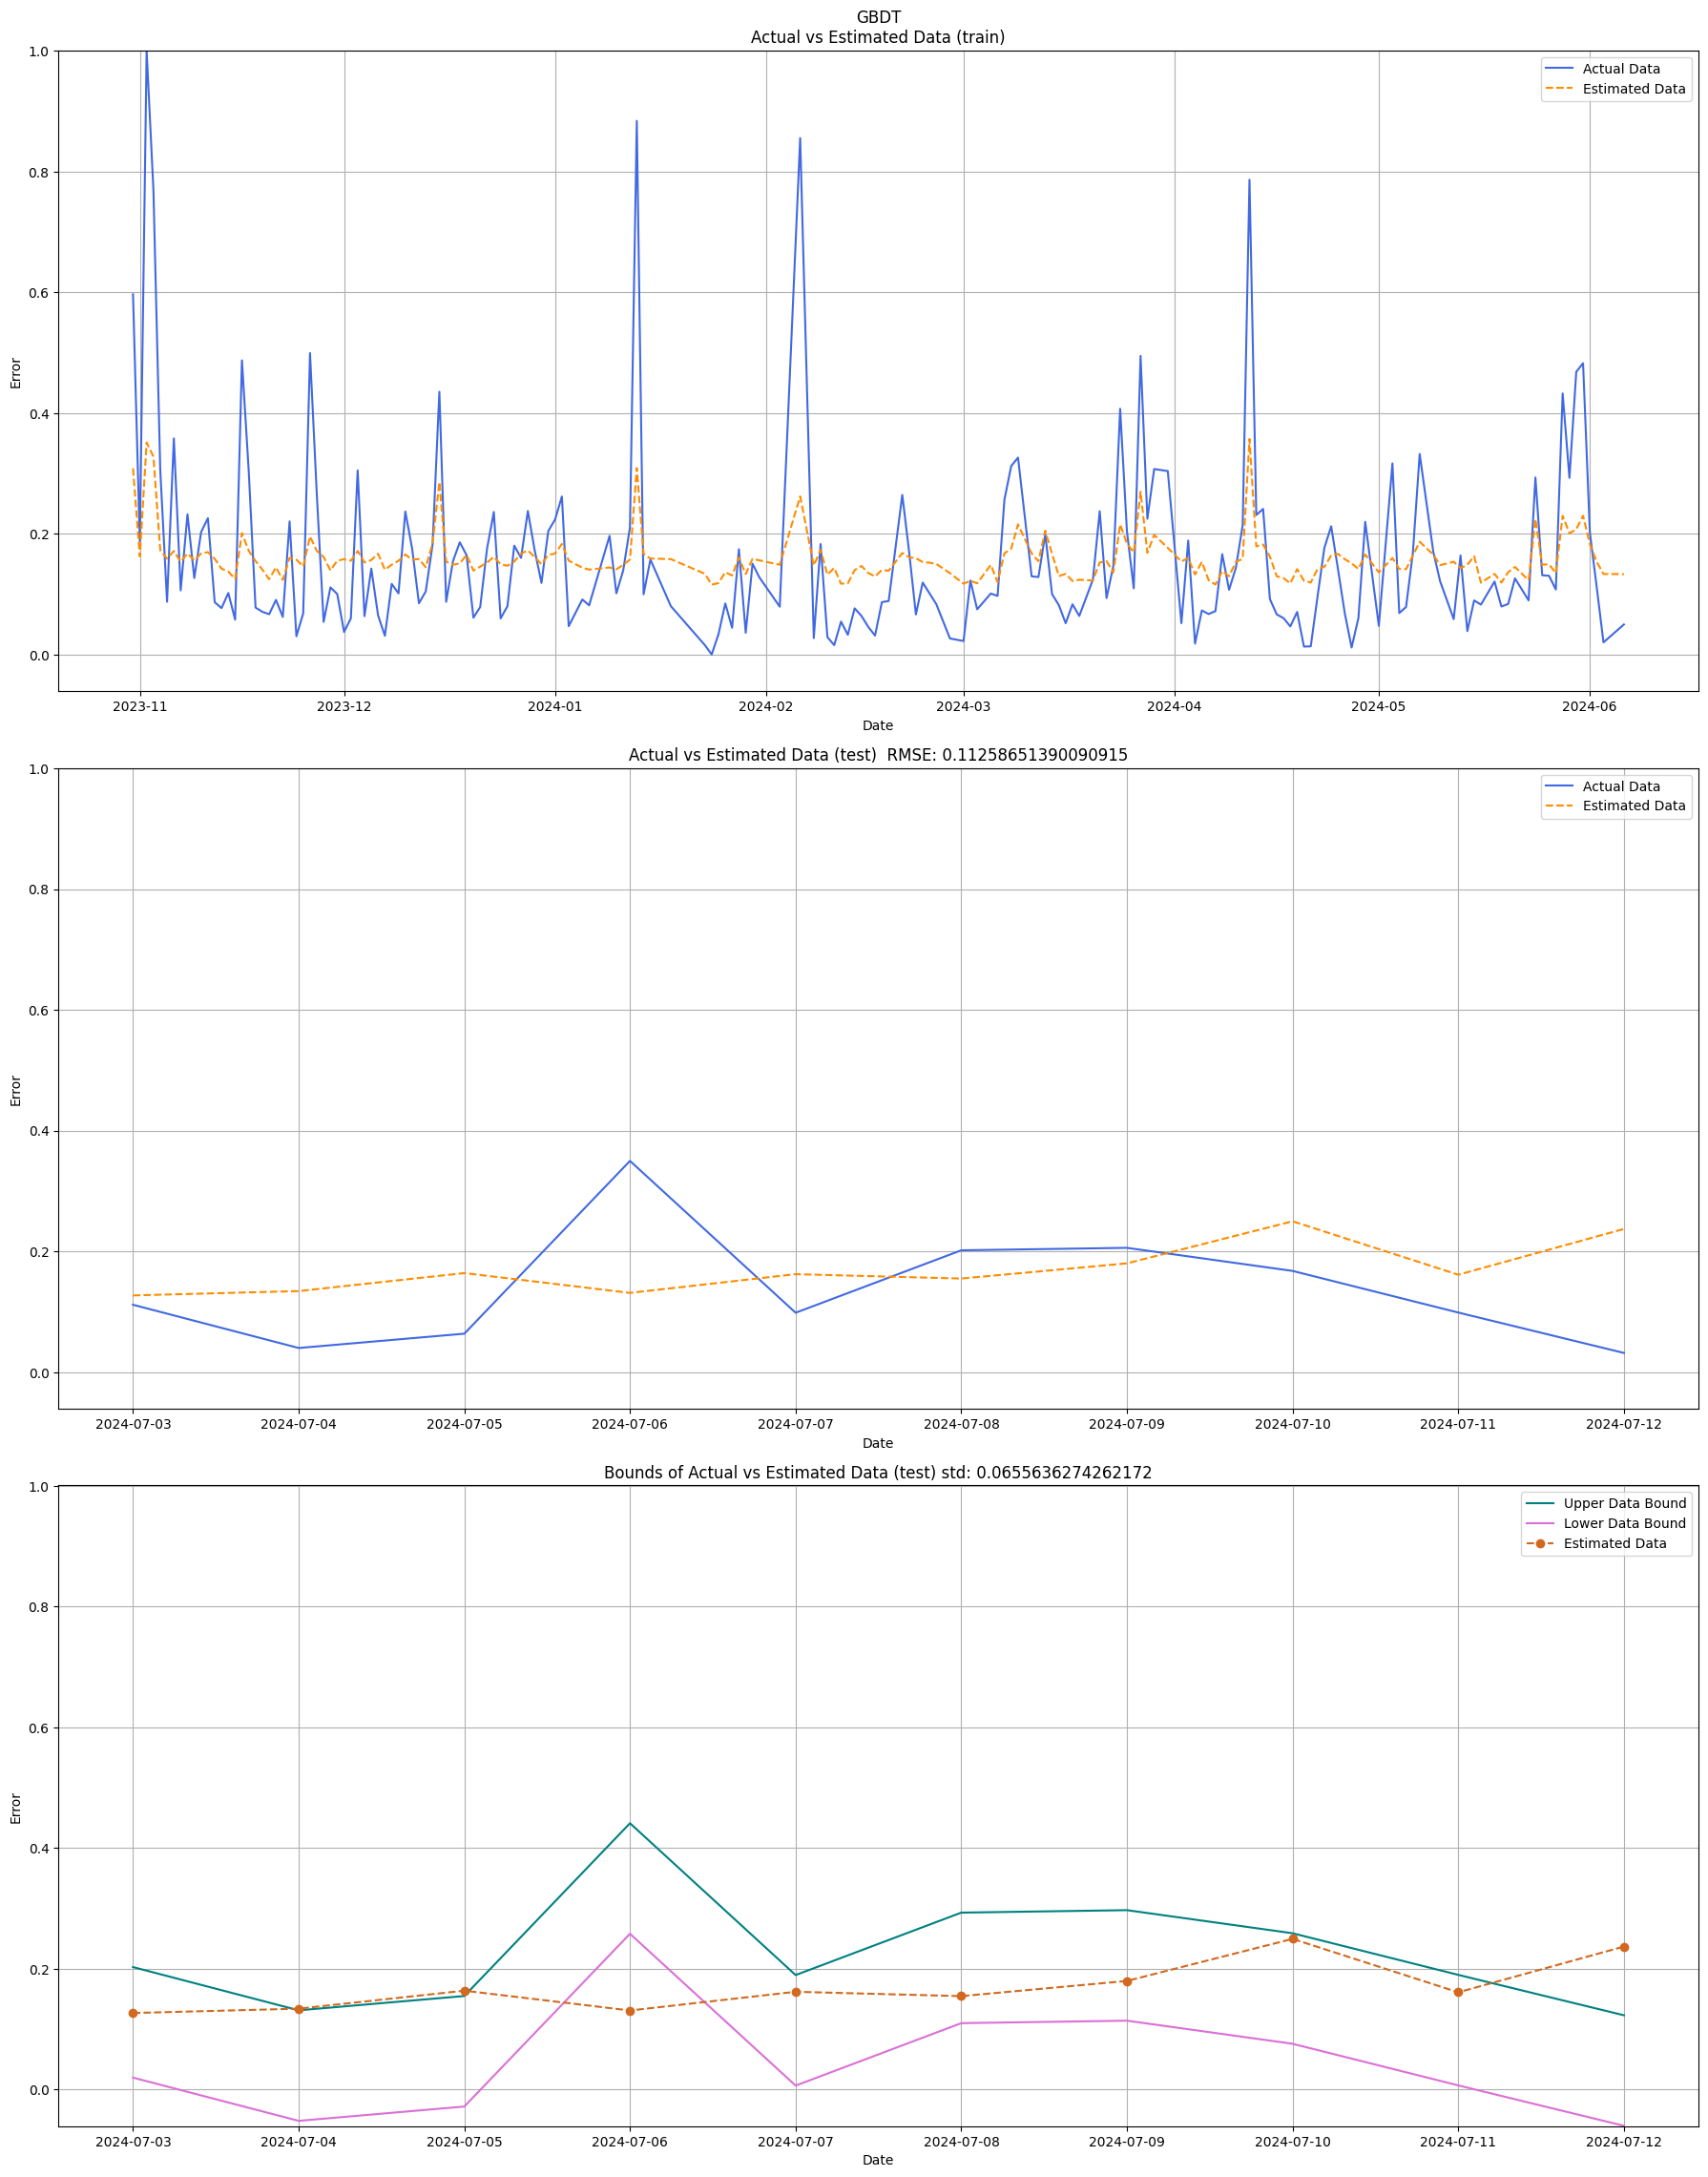

{'0-14': {'Normalized_data': True,
  'Complete_dates': 0   2023-10-31
  1   2023-11-01
  2   2023-11-02
  3   2023-11-03
  4   2023-11-04
         ...    
  5   2024-07-08
  6   2024-07-09
  7   2024-07-10
  8   2024-07-11
  9   2024-07-12
  Length: 220, dtype: datetime64[ns],
  'Complete_estimated_data': [0.3083607256412506,
   0.16249150037765503,
   0.35111096501350403,
   0.32766255736351013,
   0.17281387746334076,
   0.15866586565971375,
   0.17135794460773468,
   0.15365618467330933,
   0.16716544330120087,
   0.15583842992782593,
   0.16724802553653717,
   0.16948522627353668,
   0.1584615856409073,
   0.14207398891448975,
   0.13736674189567566,
   0.12500159442424774,
   0.20098403096199036,
   0.17164990305900574,
   0.15472567081451416,
   0.1406479924917221,
   0.1246500313282013,
   0.14432357251644135,
   0.12340046465396881,
   0.15992726385593414,
   0.1569838970899582,
   0.1456785798072815,
   0.1954885870218277,
   0.1715051680803299,
   0.16150285303592682,
   0.13

: 

In [5]:
file_path = 'up_to_15-07-2024/brisbane_0-14.xlsx'  # Update this path to the correct location of your Excel file
df = pd.read_excel(file_path)
gbdt_estimator_past(df, 10, 10, '0-14', normalize_data=True, epochs=100, save_figures=False, save_path=None, show_figs=True)